# Tutorial 5: Neighborhood Analysis

**Duration:** 20-25 minutes

This tutorial covers cellular neighborhood analysis - understanding the local microenvironment around each cell. Neighborhood composition is a powerful concept that captures how cells interact with their spatial context.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Define neighborhoods using radius-based and k-nearest neighbor methods
- Compute neighborhood composition (cell type proportions)
- Calculate diversity metrics (Shannon entropy, Simpson index)
- Identify enrichment and depletion of cell types in neighborhoods
- Find interface cells between different cell populations
- Build and analyze adjacency matrices

## Prerequisites

- Tutorials 1-4 completed
- Understanding of basic spatial statistics
- Familiarity with cell-cell interaction concepts

## Biological Context

**Why neighborhoods matter:**
- Cells don't exist in isolation - their behavior is influenced by nearby cells
- The tumor microenvironment (TME) is defined by local cell compositions
- Immune cell infiltration, exclusion, and activation depend on spatial context
- Neighborhood analysis enables discovery of cellular niches and communities

**Key applications:**
- Identifying "immune hot" vs "immune cold" tumor regions
- Detecting tumor-immune interfaces
- Characterizing stromal microenvironments
- Input for Spatial LDA (Tutorial 7)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.spatial.neighborhood import (
    compute_neighborhoods,
    neighborhood_composition,
    neighborhood_counts,
    neighborhood_diversity,
    neighborhood_enrichment,
    neighborhood_size,
    interface_cells,
    adjacency_matrix,
    type_adjacency_matrix,
    neighborhood_to_dataframe,
    window_composition,
)
from spatialtissuepy.viz import plot_spatial_scatter

# Set random seed for reproducibility
np.random.seed(42)

### Create sample tissue with distinct microenvironments

We'll create a synthetic tissue with:
- A dense tumor core
- Immune cells infiltrating the tumor margin
- Stromal cells surrounding the tumor
- Scattered macrophages throughout

In [2]:
# Tumor core (dense, centered)
tumor_coords = np.random.normal(loc=[500, 500], scale=80, size=(250, 2))
tumor_types = ['Tumor'] * 250

# CD8 T cells (infiltrating tumor margin)
cd8_near = np.random.normal(loc=[500, 500], scale=150, size=(60, 2))
cd8_far = np.random.uniform(100, 900, size=(20, 2))
cd8_coords = np.vstack([cd8_near, cd8_far])
cd8_types = ['CD8_T_cell'] * 80

# CD4 T cells (helper cells, scattered)
cd4_coords = np.random.uniform(50, 950, size=(50, 2))
cd4_types = ['CD4_T_cell'] * 50

# Stromal cells (forming ring around tumor)
theta = np.random.uniform(0, 2*np.pi, 120)
r = np.random.normal(250, 30, 120)
stromal_coords = np.column_stack([
    500 + r * np.cos(theta),
    500 + r * np.sin(theta)
]) + np.random.normal(0, 20, (120, 2))
stromal_types = ['Stromal'] * 120

# Macrophages (scattered throughout)
macro_coords = np.random.uniform(0, 1000, size=(60, 2))
macro_types = ['Macrophage'] * 60

# Combine all cells
coordinates = np.vstack([tumor_coords, cd8_coords, cd4_coords, stromal_coords, macro_coords])
cell_types = np.array(tumor_types + cd8_types + cd4_types + stromal_types + macro_types)

# Create SpatialTissueData object
tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)
print(f"\nCell types: {tissue.cell_types_unique}")

SpatialTissueData
  Cells: 560
  Dimensions: 2D
  Cell types: 5
  Bounds: x=[23.6, 994.1], y=[60.1, 991.3]

Cell types: ['CD4_T_cell' 'CD8_T_cell' 'Macrophage' 'Stromal' 'Tumor']


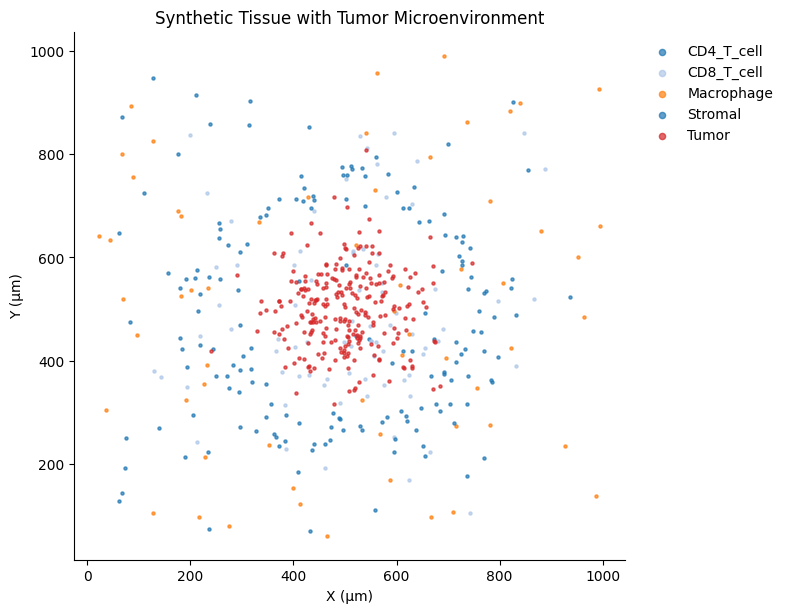

In [3]:
# Visualize the tissue
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Synthetic Tissue with Tumor Microenvironment')
plt.tight_layout()
plt.show()

## Section 1: Defining Neighborhoods

There are two main approaches to defining neighborhoods:

1. **Radius-based (fixed distance):** All cells within a specified distance
2. **k-Nearest Neighbors (k-NN):** The k closest cells regardless of distance

Each method has trade-offs:

| Method | Pros | Cons |
|--------|------|------|
| Radius | Biologically interpretable (e.g., 50μm = cell-cell contact range) | Variable neighborhood size in sparse regions |
| k-NN | Consistent neighborhood size | Distance varies, may span large areas in sparse regions |

### 1.1 Radius-Based Neighborhoods

In [4]:
# Compute radius-based neighborhoods (50μm radius)
neighborhoods_radius = compute_neighborhoods(
    tissue, 
    method='radius', 
    radius=50.0,
    include_self=False  # Don't include the focal cell
)

# Check the structure
print(f"Type: {type(neighborhoods_radius)}")
print(f"Number of cells: {len(neighborhoods_radius)}")
print(f"\nNeighbors of cell 0: {neighborhoods_radius[0]}")
print(f"Neighbors of cell 100: {neighborhoods_radius[100]}")

Type: <class 'list'>
Number of cells: 560

Neighbors of cell 0: [ 20  25  34  38  48  49  54  64  74  75  77  93  97 138 139 144 147 148
 152 154 158 159 167 169 171 176 178 182 183 188 201 220 232 238 255 275
 286 292 341 367]
Neighbors of cell 100: [ 20  29  33  40  43  45  48  52  57  72  74  75  82  86  87  92  97 103
 105 106 121 129 140 143 148 149 151 152 156 160 164 181 183 185 201 204
 220 225 233 238 292 296 309 334]


In [5]:
# Analyze neighborhood sizes
sizes = neighborhood_size(neighborhoods_radius)

print("Neighborhood size statistics (radius=50μm):")
print(f"  Mean: {sizes.mean():.1f} neighbors")
print(f"  Median: {np.median(sizes):.1f} neighbors")
print(f"  Std: {sizes.std():.1f}")
print(f"  Min: {sizes.min()}, Max: {sizes.max()}")
print(f"  Cells with 0 neighbors: {np.sum(sizes == 0)}")

Neighborhood size statistics (radius=50μm):
  Mean: 17.1 neighbors
  Median: 10.0 neighbors
  Std: 14.8
  Min: 0, Max: 53
  Cells with 0 neighbors: 23


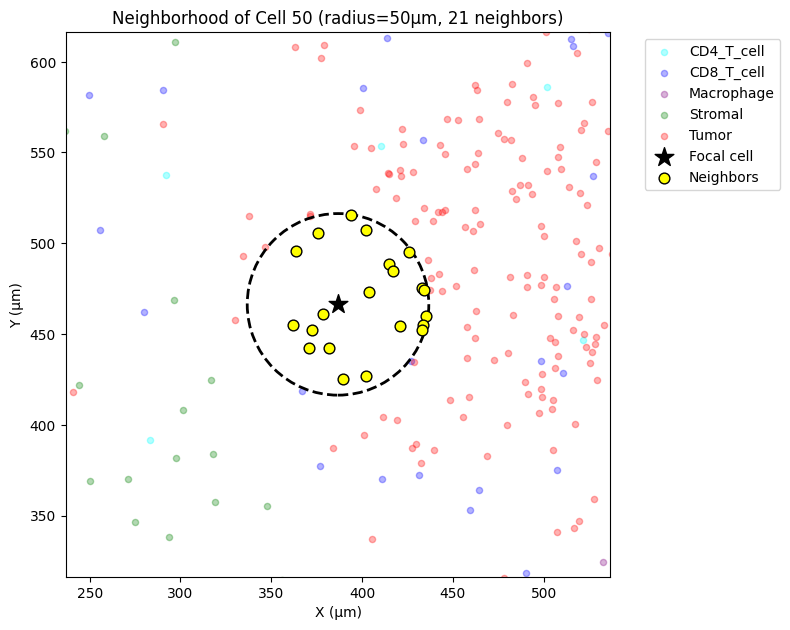

In [6]:
# Visualize a specific cell's neighborhood
focal_cell = 50  # A tumor cell in the core

fig, ax = plt.subplots(figsize=(8, 8))

# Plot all cells with low alpha
colors = {'Tumor': 'red', 'CD8_T_cell': 'blue', 'CD4_T_cell': 'cyan', 
          'Stromal': 'green', 'Macrophage': 'purple'}
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    ax.scatter(tissue.coordinates[mask, 0], tissue.coordinates[mask, 1], 
               c=colors[ct], s=20, alpha=0.3, label=ct)

# Highlight the focal cell
focal_coord = tissue.coordinates[focal_cell]
ax.scatter(*focal_coord, c='black', s=200, marker='*', zorder=5, label='Focal cell')

# Highlight neighbors
neighbor_idx = neighborhoods_radius[focal_cell]
if len(neighbor_idx) > 0:
    neighbor_coords = tissue.coordinates[neighbor_idx]
    ax.scatter(neighbor_coords[:, 0], neighbor_coords[:, 1], 
               c='yellow', s=60, edgecolors='black', zorder=4, label='Neighbors')

# Draw neighborhood circle
circle = Circle(focal_coord, 50, fill=False, edgecolor='black', linestyle='--', linewidth=2)
ax.add_patch(circle)

ax.set_xlim(focal_coord[0] - 150, focal_coord[0] + 150)
ax.set_ylim(focal_coord[1] - 150, focal_coord[1] + 150)
ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title(f'Neighborhood of Cell {focal_cell} (radius=50μm, {len(neighbor_idx)} neighbors)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 1.2 k-Nearest Neighbor Neighborhoods

In [7]:
# Compute k-NN neighborhoods (k=10)
neighborhoods_knn = compute_neighborhoods(
    tissue,
    method='knn',
    k=10,
    include_self=False
)

# All cells have exactly k neighbors
sizes_knn = neighborhood_size(neighborhoods_knn)
print(f"k-NN neighborhood size: {sizes_knn[0]} (constant for all cells)")

k-NN neighborhood size: 10 (constant for all cells)


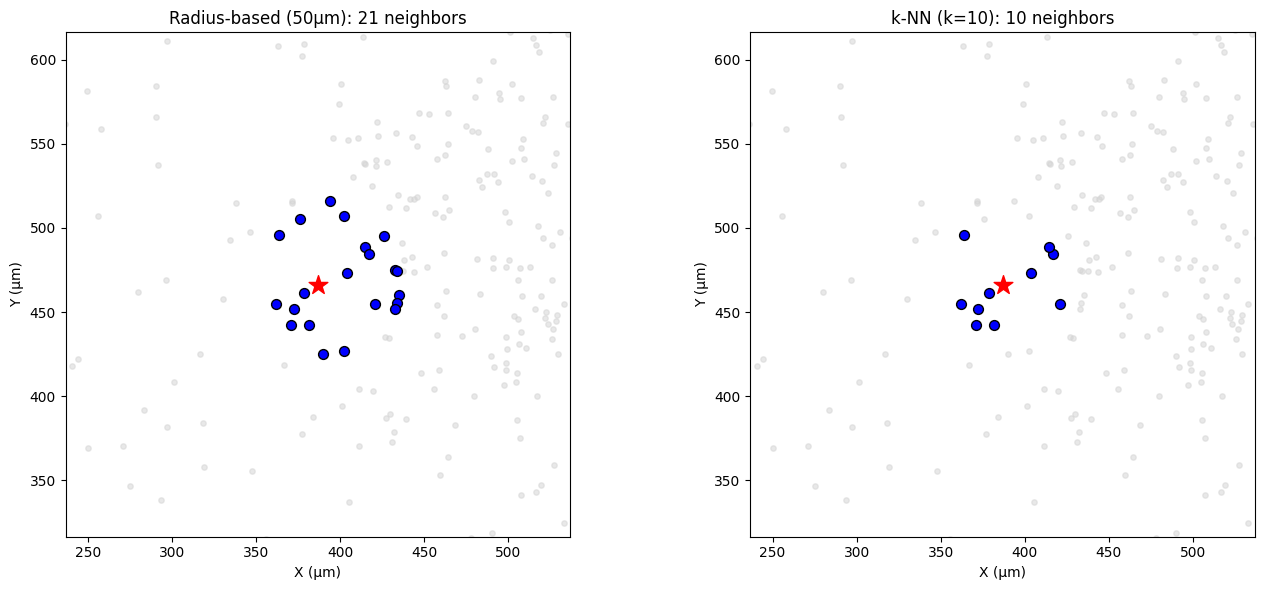

In [8]:
# Compare radius vs k-NN for the same focal cell
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

focal_cell = 50
focal_coord = tissue.coordinates[focal_cell]

for ax, (neighborhoods, title) in zip(axes, [
    (neighborhoods_radius, 'Radius-based (50μm)'),
    (neighborhoods_knn, 'k-NN (k=10)')
]):
    # Background cells
    ax.scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1], 
               c='lightgray', s=15, alpha=0.5)
    
    # Focal cell
    ax.scatter(*focal_coord, c='red', s=200, marker='*', zorder=5)
    
    # Neighbors
    neighbor_idx = neighborhoods[focal_cell]
    neighbor_coords = tissue.coordinates[neighbor_idx]
    ax.scatter(neighbor_coords[:, 0], neighbor_coords[:, 1], 
               c='blue', s=50, edgecolors='black', zorder=4)
    
    ax.set_xlim(focal_coord[0] - 150, focal_coord[0] + 150)
    ax.set_ylim(focal_coord[1] - 150, focal_coord[1] + 150)
    ax.set_title(f'{title}: {len(neighbor_idx)} neighbors')
    ax.set_xlabel('X (μm)')
    ax.set_ylabel('Y (μm)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Section 2: Neighborhood Composition

Neighborhood composition captures the cell type proportions around each cell. This is the key input for understanding local microenvironments.

### 2.1 Computing Composition

In [9]:
# Compute neighborhood composition (proportions)
composition = neighborhood_composition(
    tissue,
    method='radius',
    radius=50.0,
    normalize=True  # Proportions sum to 1
)

print(f"Composition matrix shape: {composition.shape}")
print(f"Rows: {composition.shape[0]} cells")
print(f"Columns: {composition.shape[1]} cell types")
print(f"\nColumn order: {list(tissue.cell_types_unique)}")
print(f"\nExample composition (cell 0): {composition[0].round(3)}")
print(f"Sum of proportions: {composition[0].sum():.4f}")

Composition matrix shape: (560, 5)
Rows: 560 cells
Columns: 5 cell types

Column order: [np.str_('CD4_T_cell'), np.str_('CD8_T_cell'), np.str_('Macrophage'), np.str_('Stromal'), np.str_('Tumor')]

Example composition (cell 0): [0.05 0.1  0.   0.   0.85]
Sum of proportions: 1.0000


In [10]:
# Get counts instead of proportions
counts = neighborhood_counts(tissue, neighborhoods_radius)

print(f"Counts matrix shape: {counts.shape}")
print(f"\nExample counts (cell 0): {counts[0]}")
print(f"Total neighbors: {counts[0].sum()}")

Counts matrix shape: (560, 5)

Example counts (cell 0): [ 2  4  0  0 34]
Total neighbors: 40


### 2.2 Comparing Compositions by Cell Type

Do different cell types have different neighborhood compositions?

In [11]:
# Compute mean composition for each cell type
composition_df = neighborhood_to_dataframe(
    tissue,
    method='radius',
    radius=50.0
)

print("Mean neighborhood composition by cell type:")
print(composition_df.groupby('cell_type')[list(tissue.cell_types_unique)].mean().round(3))

Mean neighborhood composition by cell type:
            CD4_T_cell  CD8_T_cell  Macrophage  Stromal  Tumor
cell_type                                                     
CD4_T_cell       0.176       0.154       0.237    0.213  0.100
CD8_T_cell       0.091       0.135       0.095    0.200  0.441
Macrophage       0.206       0.110       0.164    0.204  0.081
Stromal          0.083       0.119       0.109    0.609  0.079
Tumor            0.023       0.137       0.019    0.040  0.782


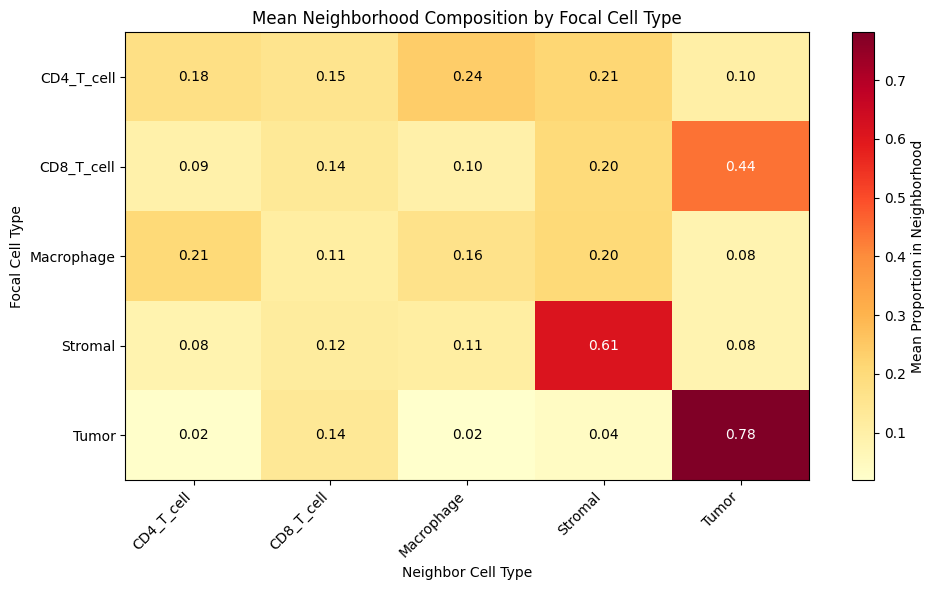


Interpretation:
- High diagonal values = homotypic clustering (cells near same type)
- Tumor cells have mostly Tumor neighbors (dense core)
- CD8 T cells have mixed neighborhoods (infiltrating)


In [12]:
# Visualize as heatmap
mean_comp = composition_df.groupby('cell_type')[list(tissue.cell_types_unique)].mean()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(mean_comp.values, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(range(len(mean_comp.columns)))
ax.set_xticklabels(mean_comp.columns, rotation=45, ha='right')
ax.set_yticks(range(len(mean_comp.index)))
ax.set_yticklabels(mean_comp.index)

# Colorbar
plt.colorbar(im, label='Mean Proportion in Neighborhood')

# Annotate cells
for i in range(len(mean_comp.index)):
    for j in range(len(mean_comp.columns)):
        val = mean_comp.values[i, j]
        color = 'white' if val > 0.3 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)

ax.set_xlabel('Neighbor Cell Type')
ax.set_ylabel('Focal Cell Type')
ax.set_title('Mean Neighborhood Composition by Focal Cell Type')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High diagonal values = homotypic clustering (cells near same type)")
print("- Tumor cells have mostly Tumor neighbors (dense core)")
print("- CD8 T cells have mixed neighborhoods (infiltrating)")

## Section 3: Neighborhood Diversity

Diversity metrics quantify how mixed the neighborhood is. High diversity indicates a heterogeneous microenvironment; low diversity indicates homogeneous regions.

### Available metrics:
- **Shannon entropy:** -Σ(p × log(p)), sensitive to rare types
- **Simpson's index:** 1 - Σ(p²), probability two random neighbors differ
- **Richness:** Number of cell types present

In [13]:
# Compute diversity metrics
shannon = neighborhood_diversity(tissue, neighborhoods_radius, metric='shannon')
simpson = neighborhood_diversity(tissue, neighborhoods_radius, metric='simpson')
richness = neighborhood_diversity(tissue, neighborhoods_radius, metric='richness')

print("Diversity Statistics:")
print(f"\nShannon Entropy:")
print(f"  Mean: {shannon.mean():.3f}, Range: [{shannon.min():.3f}, {shannon.max():.3f}]")
print(f"\nSimpson's Index:")
print(f"  Mean: {simpson.mean():.3f}, Range: [{simpson.min():.3f}, {simpson.max():.3f}]")
print(f"\nRichness (number of types):")
print(f"  Mean: {richness.mean():.1f}, Range: [{richness.min():.0f}, {richness.max():.0f}]")

Diversity Statistics:

Shannon Entropy:
  Mean: 0.569, Range: [-0.000, 1.609]

Simpson's Index:
  Mean: 0.365, Range: [0.000, 1.000]

Richness (number of types):
  Mean: 2.6, Range: [0, 5]


In [14]:
# Compare diversity by cell type
print("Mean Shannon Diversity by Cell Type:")
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    mean_div = shannon[mask].mean()
    print(f"  {ct}: {mean_div:.3f}")

Mean Shannon Diversity by Cell Type:
  CD4_T_cell: 0.344
  CD8_T_cell: 0.626
  Macrophage: 0.359
  Stromal: 0.815
  Tumor: 0.529


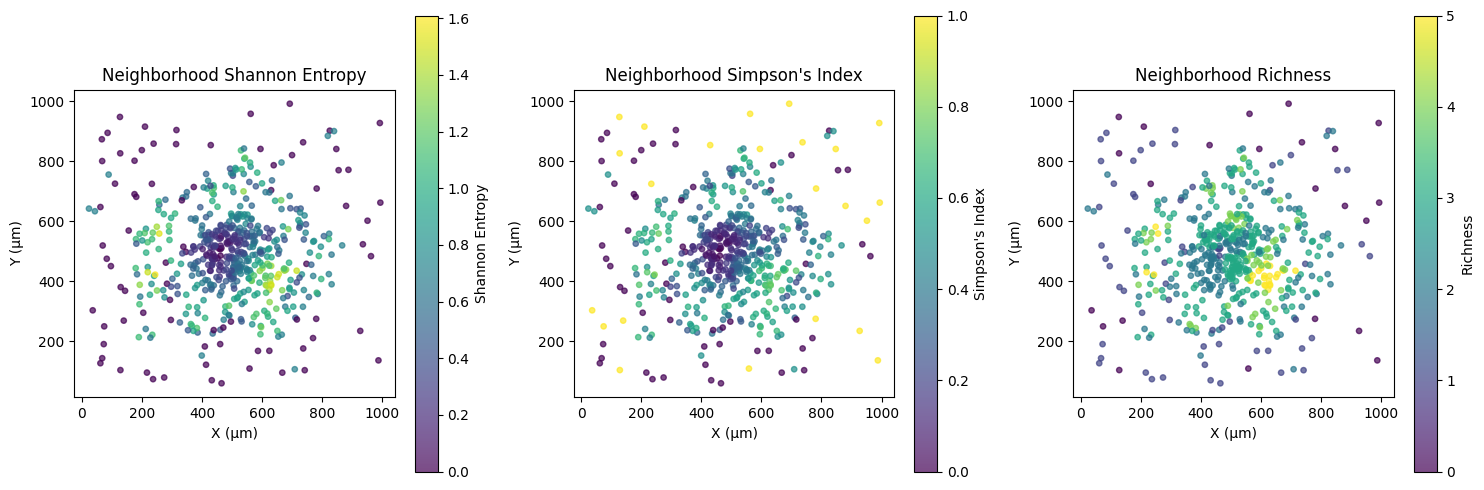


Interpretation:
- Low diversity in tumor core (homogeneous)
- High diversity at tumor margin (mixed cell types)
- Diversity gradients reveal tissue architecture


In [15]:
# Visualize diversity across the tissue
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('Shannon Entropy', shannon), 
           ("Simpson's Index", simpson), 
           ('Richness', richness)]

for ax, (name, values) in zip(axes, metrics):
    scatter = ax.scatter(
        tissue.coordinates[:, 0],
        tissue.coordinates[:, 1],
        c=values,
        cmap='viridis',
        s=15,
        alpha=0.7
    )
    plt.colorbar(scatter, ax=ax, label=name)
    ax.set_xlabel('X (μm)')
    ax.set_ylabel('Y (μm)')
    ax.set_title(f'Neighborhood {name}')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Low diversity in tumor core (homogeneous)")
print("- High diversity at tumor margin (mixed cell types)")
print("- Diversity gradients reveal tissue architecture")

## Section 4: Neighborhood Enrichment

Enrichment analysis determines whether a cell type is over- or under-represented in neighborhoods compared to its global proportion.

- **Enrichment > 1:** Cell type is more common locally than globally (enriched)
- **Enrichment = 1:** Local proportion matches global proportion
- **Enrichment < 1:** Cell type is less common locally (depleted)

In [16]:
# Compute enrichment for each cell type
enrichment_results = {}
for ct in tissue.cell_types_unique:
    enrichment_results[ct] = neighborhood_enrichment(
        tissue, neighborhoods_radius, target_type=ct
    )

print("Mean Enrichment by Focal Cell Type:")
print("(Values > 1 = enriched, < 1 = depleted)\n")

# Create summary table
for focal_type in tissue.cell_types_unique:
    mask = tissue.cell_types == focal_type
    print(f"{focal_type}:")
    for target_type in tissue.cell_types_unique:
        mean_enrich = enrichment_results[target_type][mask].mean()
        status = "enriched" if mean_enrich > 1.2 else "depleted" if mean_enrich < 0.8 else "neutral"
        print(f"  {target_type}: {mean_enrich:.2f} ({status})")
    print()

Mean Enrichment by Focal Cell Type:
(Values > 1 = enriched, < 1 = depleted)

CD4_T_cell:
  CD4_T_cell: 1.97 (enriched)
  CD8_T_cell: 1.08 (neutral)
  Macrophage: 2.21 (enriched)
  Stromal: 0.99 (neutral)
  Tumor: 0.22 (depleted)

CD8_T_cell:
  CD4_T_cell: 1.02 (neutral)
  CD8_T_cell: 0.95 (neutral)
  Macrophage: 0.89 (neutral)
  Stromal: 0.93 (neutral)
  Tumor: 0.99 (neutral)

Macrophage:
  CD4_T_cell: 2.31 (enriched)
  CD8_T_cell: 0.77 (depleted)
  Macrophage: 1.53 (enriched)
  Stromal: 0.95 (neutral)
  Tumor: 0.18 (depleted)

Stromal:
  CD4_T_cell: 0.93 (neutral)
  CD8_T_cell: 0.84 (neutral)
  Macrophage: 1.02 (neutral)
  Stromal: 2.84 (enriched)
  Tumor: 0.18 (depleted)

Tumor:
  CD4_T_cell: 0.25 (depleted)
  CD8_T_cell: 0.96 (neutral)
  Macrophage: 0.18 (depleted)
  Stromal: 0.18 (depleted)
  Tumor: 1.75 (enriched)



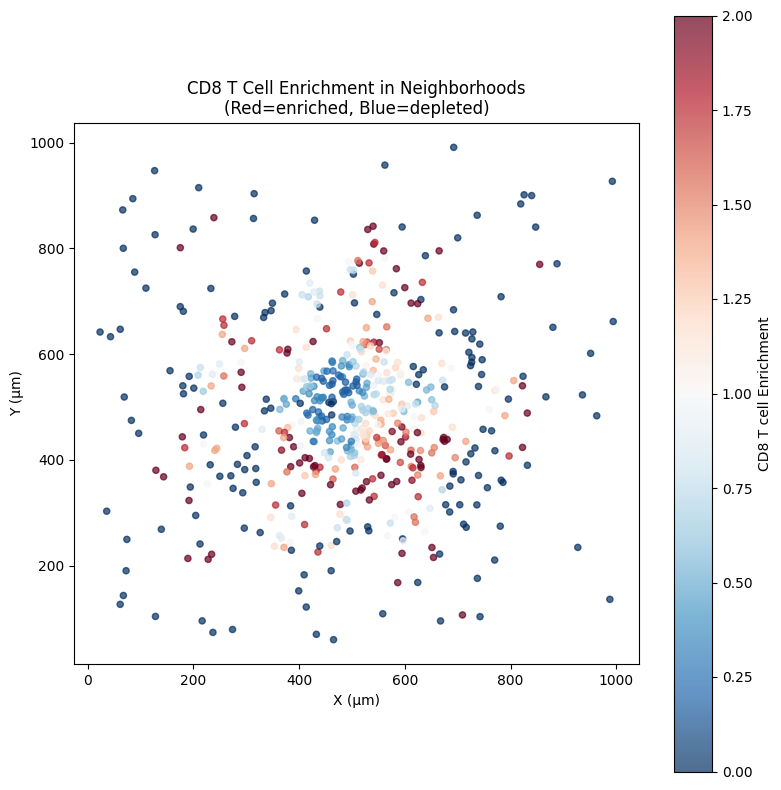

In [17]:
# Visualize CD8 T cell enrichment across the tissue
cd8_enrichment = enrichment_results['CD8_T_cell']

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=cd8_enrichment,
    cmap='RdBu_r',
    vmin=0, vmax=2,  # Center at 1
    s=20,
    alpha=0.7
)
plt.colorbar(scatter, label='CD8 T cell Enrichment')

ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('CD8 T Cell Enrichment in Neighborhoods\n(Red=enriched, Blue=depleted)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Section 5: Interface Cell Detection

Interface cells are those at the boundary between two cell populations. They are particularly important in:
- Tumor-immune interfaces (where immune attack occurs)
- Tissue boundaries
- Invasion fronts

In [18]:
# Find tumor cells at the tumor-immune interface
tumor_interface, cd8_interface = interface_cells(
    tissue,
    type_a='Tumor',
    type_b='CD8_T_cell',
    radius=50.0,
    min_neighbors=1  # At least 1 CD8 T cell neighbor
)

print(f"Tumor cells at interface: {len(tumor_interface)} / {np.sum(tissue.cell_types == 'Tumor')}")
print(f"CD8 T cells at interface: {len(cd8_interface)} / {np.sum(tissue.cell_types == 'CD8_T_cell')}")
print(f"\nPercentage of Tumor at interface: {100 * len(tumor_interface) / np.sum(tissue.cell_types == 'Tumor'):.1f}%")
print(f"Percentage of CD8 at interface: {100 * len(cd8_interface) / np.sum(tissue.cell_types == 'CD8_T_cell'):.1f}%")

Tumor cells at interface: 234 / 250
CD8 T cells at interface: 56 / 80

Percentage of Tumor at interface: 93.6%
Percentage of CD8 at interface: 70.0%


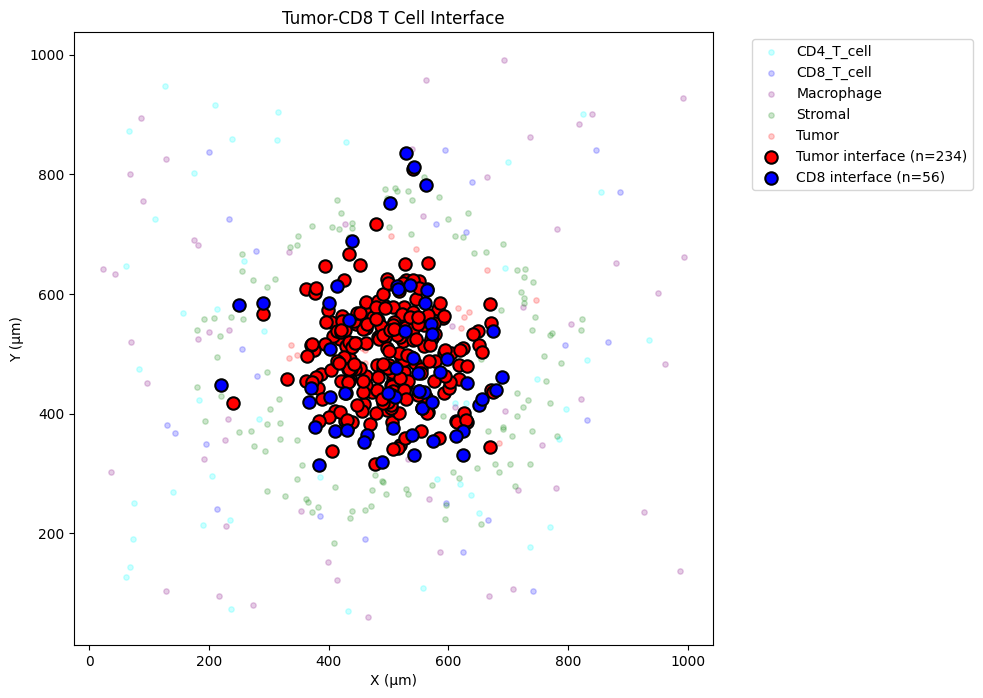


Biological interpretation:
- Interface cells are potential sites of immune engagement
- High interface % suggests good immune infiltration
- Low interface % may indicate immune exclusion


In [19]:
# Visualize interface cells
fig, ax = plt.subplots(figsize=(10, 10))

# Non-interface cells (faded)
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    ax.scatter(tissue.coordinates[mask, 0], tissue.coordinates[mask, 1], 
               c=colors[ct], s=15, alpha=0.2, label=ct)

# Interface tumor cells
ax.scatter(tissue.coordinates[tumor_interface, 0], tissue.coordinates[tumor_interface, 1],
           c='red', s=80, edgecolors='black', linewidths=1.5, 
           label=f'Tumor interface (n={len(tumor_interface)})')

# Interface CD8 T cells
ax.scatter(tissue.coordinates[cd8_interface, 0], tissue.coordinates[cd8_interface, 1],
           c='blue', s=80, edgecolors='black', linewidths=1.5,
           label=f'CD8 interface (n={len(cd8_interface)})')

ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('Tumor-CD8 T Cell Interface')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\nBiological interpretation:")
print("- Interface cells are potential sites of immune engagement")
print("- High interface % suggests good immune infiltration")
print("- Low interface % may indicate immune exclusion")

## Section 6: Adjacency Matrices

Adjacency matrices represent cell-cell spatial relationships as a graph structure. They're useful for:
- Network analysis (Tutorial 6)
- Identifying cell communities
- Computing type-type interaction statistics

In [20]:
# Compute cell-cell adjacency matrix
adj = adjacency_matrix(
    tissue,
    method='radius',
    radius=50.0,
    weighted=False,  # Binary adjacency
    sparse=True  # Return sparse matrix for efficiency
)

print(f"Adjacency matrix shape: {adj.shape}")
print(f"Number of edges: {adj.nnz // 2}")
print(f"Matrix density: {100 * adj.nnz / (adj.shape[0]**2):.2f}%")
print(f"\nMean degree: {adj.sum(axis=1).mean():.1f}")

Adjacency matrix shape: (560, 560)
Number of edges: 4774
Matrix density: 3.04%

Mean degree: 17.1


In [21]:
# Compute type-type adjacency matrix
type_adj = type_adjacency_matrix(
    tissue,
    method='radius',
    radius=50.0,
    normalize='none'  # Raw counts
)

print("Type-Type Adjacency (edge counts):")
print(type_adj.astype(int))

Type-Type Adjacency (edge counts):
            CD4_T_cell  CD8_T_cell  Macrophage  Stromal  Tumor
CD4_T_cell          20          52          26       63    151
CD8_T_cell          52         152          42       98    793
Macrophage          26          42          22       81     86
Stromal             63          98          81      498     82
Tumor              151         793          86       82   5908


In [22]:
# Normalize to see interaction preferences
type_adj_expected = type_adjacency_matrix(
    tissue,
    method='radius',
    radius=50.0,
    normalize='expected'  # Ratio to expected under random mixing
)

print("Type-Type Adjacency (observed/expected):")
print(type_adj_expected.round(2))
print("\n> 1: More interactions than expected (attraction)")
print("< 1: Fewer interactions than expected (avoidance)")

Type-Type Adjacency (observed/expected):
            CD4_T_cell  CD8_T_cell  Macrophage  Stromal  Tumor
CD4_T_cell        0.26        0.43        0.28     0.34   0.40
CD8_T_cell        0.43        0.78        0.29     0.34   1.30
Macrophage        0.28        0.29        0.20     0.37   0.19
Stromal           0.34        0.34        0.37     1.14   0.09
Tumor             0.40        1.30        0.19     0.09   3.10

> 1: More interactions than expected (attraction)
< 1: Fewer interactions than expected (avoidance)


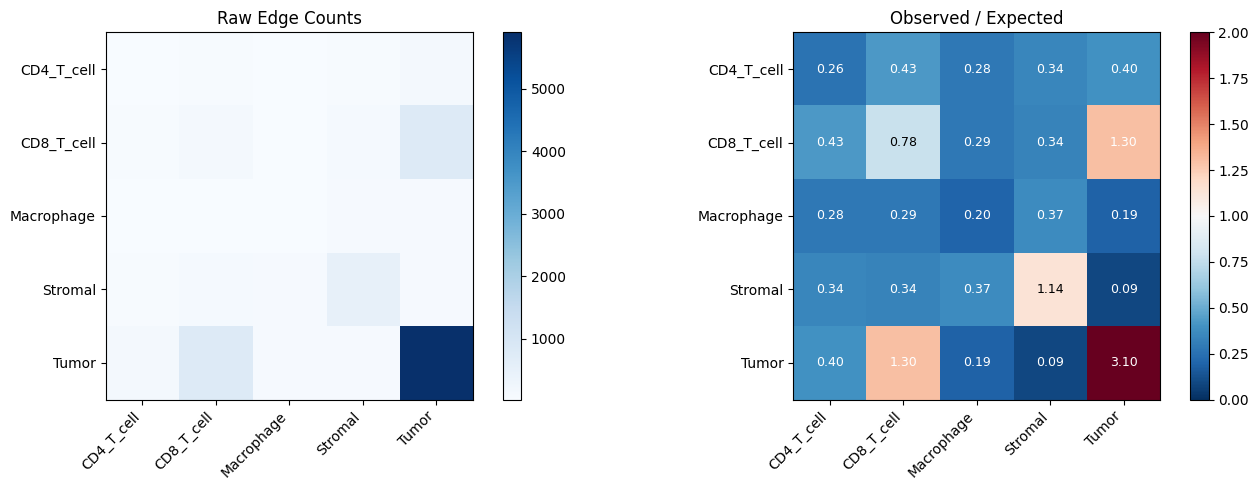

In [23]:
# Visualize type-type adjacency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im1 = axes[0].imshow(type_adj.values, cmap='Blues')
axes[0].set_xticks(range(len(type_adj.columns)))
axes[0].set_xticklabels(type_adj.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(type_adj.index)))
axes[0].set_yticklabels(type_adj.index)
axes[0].set_title('Raw Edge Counts')
plt.colorbar(im1, ax=axes[0])

# Observed/Expected
im2 = axes[1].imshow(type_adj_expected.values, cmap='RdBu_r', vmin=0, vmax=2)
axes[1].set_xticks(range(len(type_adj_expected.columns)))
axes[1].set_xticklabels(type_adj_expected.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(type_adj_expected.index)))
axes[1].set_yticklabels(type_adj_expected.index)
axes[1].set_title('Observed / Expected')
plt.colorbar(im2, ax=axes[1])

# Annotate
for i in range(len(type_adj_expected.index)):
    for j in range(len(type_adj_expected.columns)):
        val = type_adj_expected.values[i, j]
        color = 'white' if val > 1.3 or val < 0.7 else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.show()

## Section 7: Window-Based Composition Analysis

For larger-scale spatial patterns, we can compute composition in sliding windows across the tissue.

In [24]:
# Compute composition in 200x200 μm windows
window_comp, window_centers = window_composition(
    tissue,
    window_size=200,
    grid_step=100,  # 50% overlap
    min_cells=5
)

print(f"Number of windows: {len(window_centers)}")
print(f"Composition shape: {window_comp.shape}")

Number of windows: 63
Composition shape: (63, 5)


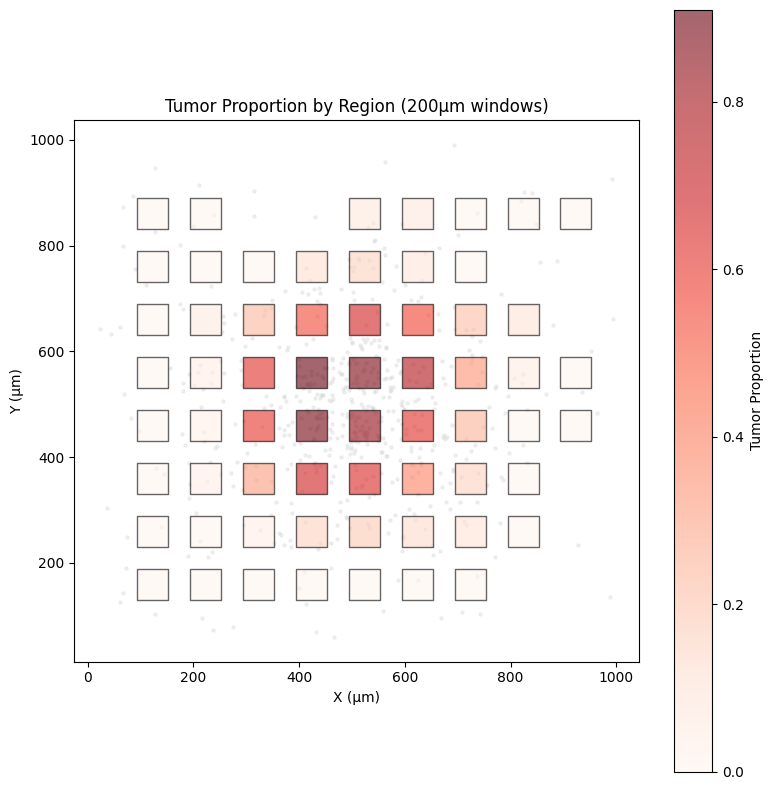

In [25]:
# Visualize tumor proportion across windows
tumor_idx = list(tissue.cell_types_unique).index('Tumor')
tumor_prop = window_comp[:, tumor_idx]

fig, ax = plt.subplots(figsize=(8, 8))

# Background cells
ax.scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
           c='lightgray', s=5, alpha=0.3)

# Windows colored by tumor proportion
scatter = ax.scatter(
    window_centers[:, 0],
    window_centers[:, 1],
    c=tumor_prop,
    cmap='Reds',
    s=500,
    marker='s',
    alpha=0.6,
    edgecolors='black'
)
plt.colorbar(scatter, label='Tumor Proportion')

ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('Tumor Proportion by Region (200μm windows)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Exercise: Analyze Immune Infiltration Patterns

Try the following analyses:

1. **Multi-scale neighborhoods:** Compare neighborhood compositions at different radii (30, 50, 100 μm). How do patterns change with scale?

2. **Immune infiltration score:** Compute the proportion of CD8 T cells that are within 50μm of a tumor cell. This is a measure of immune infiltration.

3. **Stromal barrier:** Find stromal cells that are between tumor and immune cells. These may form a physical barrier to immune infiltration.

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Neighborhood definition:** Radius-based vs k-NN methods, with trade-offs for each
- **Composition analysis:** Computing cell type proportions in local neighborhoods
- **Diversity metrics:** Shannon entropy, Simpson's index, and richness to quantify microenvironment heterogeneity
- **Enrichment analysis:** Detecting over/under-representation of cell types
- **Interface detection:** Finding cells at boundaries between populations
- **Adjacency matrices:** Representing spatial relationships as graphs

**Key biological insights:**
- Neighborhood composition reveals the local microenvironment context
- Diversity gradients highlight tissue architecture and transition zones
- Interface cells are hotspots for cell-cell interactions
- These metrics are essential inputs for Spatial LDA (Tutorial 7)

## Next Steps

- **Tutorial 6: Network Analysis** - Build graphs from spatial relationships and analyze network properties
- **Tutorial 7: Spatial LDA** - Use neighborhood compositions to discover recurrent cellular niches